In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

from arch import arch_model
from scipy.stats import chi2, jarque_bera
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, adfuller
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.arima.model import ARIMA

In [2]:
import numpy as np
from scipy.stats import chi2

def mcleod_li_test(residuals, k):
    """
    Calculates the McLeod-Li test statistic for a time series with k lags.
    Returns the test statistic and its p-value.
    
    H0: No significant autocorrelation in the squared residuals --> Homocedasticity.
    Args:
        - residuals: residuals serie
        - k (int): lags
    Return:
        - stat
        - p-value
    """
    n = len(residuals)
    residuals_sq = residuals ** 2

    x_sum = np.sum(residuals_sq)
    x_lag_sum = np.sum(residuals_sq[k:])  # sum from index k to n

    test_stat = (n * (n + 2) * x_lag_sum) / (x_sum ** 2)
    
    df = k
    
    p_value = 1 - chi2.cdf(test_stat, df)
    
    return test_stat, p_value


Data

In [3]:
start_date = "2021-01-04"
end_date   = "2024-12-31"

ticker = "SPY"

stock = yf.Ticker(ticker)
hist = stock.history(start = start_date, end = end_date)
df = pd.DataFrame(hist, columns=['Close'])

In [4]:
# Convert prices to log returns 
df['log_return'] = np.log(df['Close']).diff() * 100
df.dropna(inplace=True)

Text(0.5, 1.0, 'Returns of SPY')

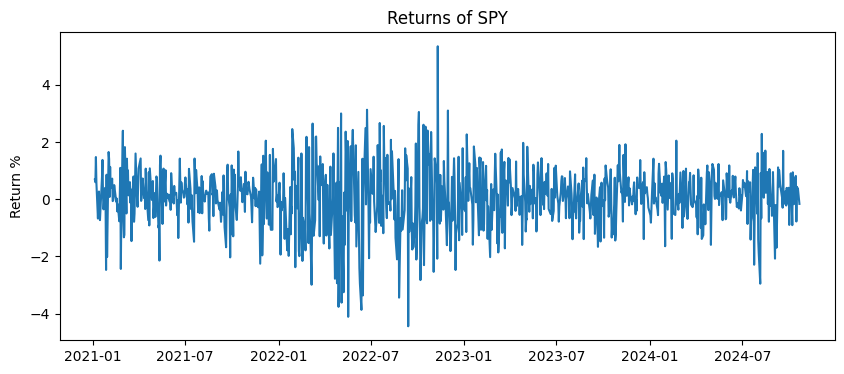

In [5]:
# Add trace plot
plt.figure(figsize=(10,4))
plt.plot(df['log_return'])
plt.ylabel("Return %")
plt.title(f'Returns of {ticker}')

Model

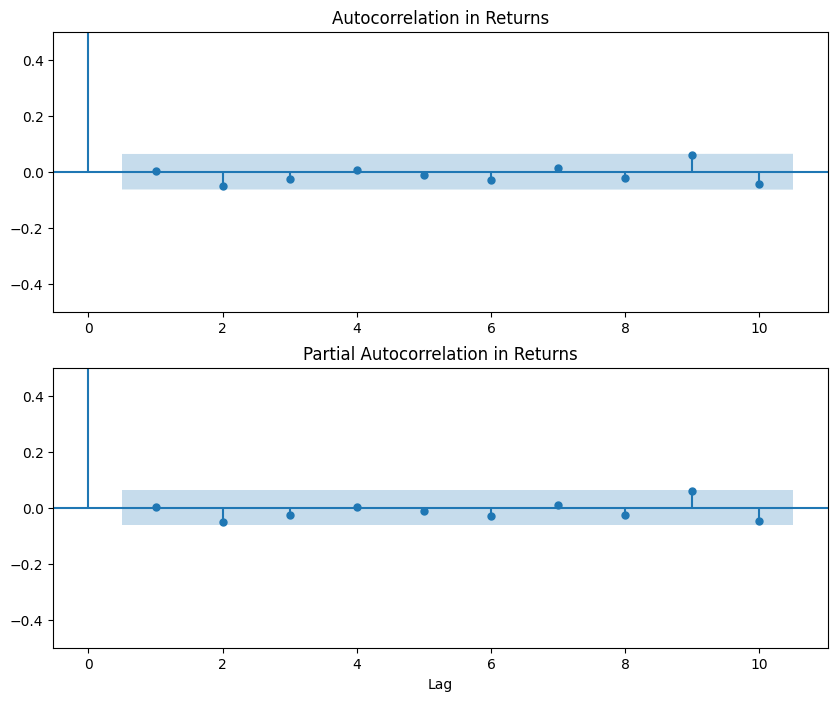

In [6]:
diff_ts = df['log_return'].iloc[1:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(diff_ts, ax=ax1, lags=10)
ax1.set_ylim(-0.5, .5) 
ax1.set_title("Autocorrelation in Returns")
plot_pacf(diff_ts, ax=ax2, lags=10)
ax2.set_ylim(-0.5, .5)  
ax2.set_xlabel("Lag")  
ax2.set_title("Partial Autocorrelation in Returns")

plt.show()

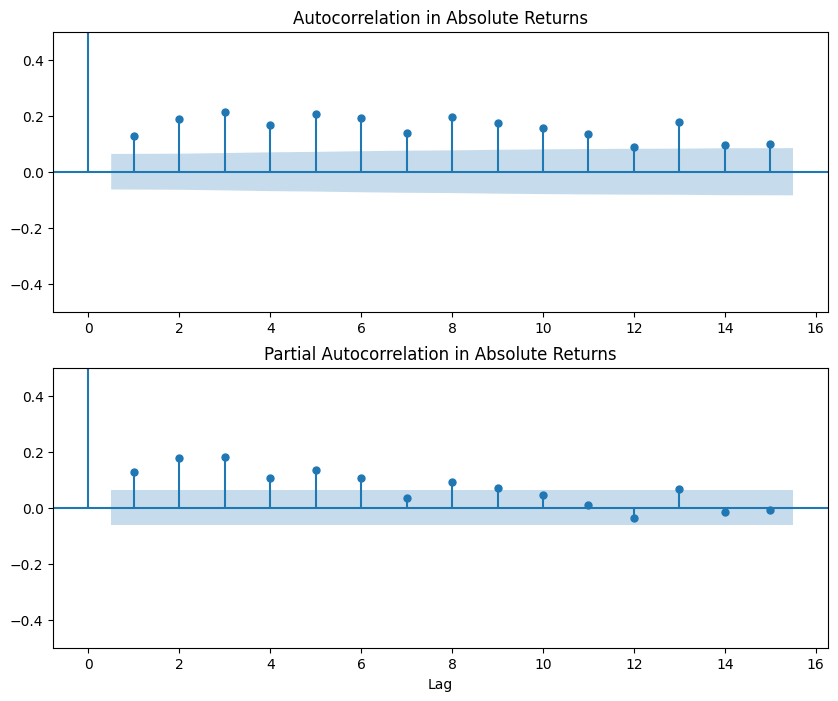

In [7]:
# Compute absolute returns: measure magnitude
abs_returns = diff_ts.abs()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(abs_returns, ax=ax1, lags=15)
ax1.set_ylim(-.5, .5) 
ax1.set_title("Autocorrelation in Absolute Returns")
plot_pacf(abs_returns, ax=ax2, lags=15)
ax2.set_ylim(-.5, .5)  
ax2.set_title("Partial Autocorrelation in Absolute Returns")
ax2.set_xlabel("Lag")  

plt.show()

In [8]:
# test_stat, p_value = mcleod_li_test(abs_returns, 50)
# print("McLeod-Li test statistic: ", test_stat)
# print("p-value: ", p_value)

# if p_value < 0.05:
#     print("Reject H0: No significant autocorrelation in the squared residuals. (Heterocedasticity)")
# else:
#     print("No reject H0: No significant autocorrelation in the squared residuals. (Homocedasticity)")

Train Test split

In [9]:
y_train, y_test = train_test_split(diff_ts, train_size=0.8, shuffle=False)

Model

In [10]:
from arch import arch_model
import pandas as pd
from tqdm import tqdm  # Importar tqdm

results_list = []

p_values = [1, 2, 3, 4, 5, 6, 7, 8, 9]
q_values = [1, 2, 3, 4, 5, 6, 7, 8, 9]
distributions = ['normal', 't']

total_iterations = len(p_values) * len(q_values) * len(distributions)

with tqdm(total=total_iterations, desc='Fitting GARCH Models') as pbar:
    for p in p_values:
        for q in q_values:
            for dist in distributions:
                model = arch_model(y_train, mean='Zero', vol='Garch', p=p, q=q, dist=dist)
                res = model.fit(disp='off')
                
                results_list.append([
                    f'GARCH({p},{q})', p, q, dist, res.aic, res.bic])
                
                pbar.update(1)

results = pd.DataFrame(results_list, columns=['Model', 'p', 'q', 'Dist', 'AIC', 'BIC'])

best_model_aic = results.loc[results['AIC'].idxmin()]
best_model_bic = results.loc[results['BIC'].idxmin()]


Fitting GARCH Models: 100%|██████████| 162/162 [00:13<00:00, 12.31it/s]


In [11]:
print("Best model based on AIC:")
print(best_model_aic)

print("\nBest model based on BIC:")
print(best_model_bic)

Best model based on AIC:
Model     GARCH(1,1)
p                  1
q                  1
Dist               t
AIC      2173.005979
BIC      2191.555012
Name: 1, dtype: object

Best model based on BIC:
Model     GARCH(1,1)
p                  1
q                  1
Dist          normal
AIC      2174.449903
BIC      2188.361677
Name: 0, dtype: object


In [12]:
# Fit GARCH (1,1)
# y_train, y_test = train_test_split(abs_returns, train_size= 0.8)

garch_mod = arch_model(y_train, mean = "Zero",  vol='Garch', p=1, q=1, rescale=False)
res_garch = garch_mod.fit()

Iteration:      1,   Func. Count:      5,   Neg. LLF: 3808.0783395694652
Iteration:      2,   Func. Count:     14,   Neg. LLF: 244999.01124706815
Iteration:      3,   Func. Count:     19,   Neg. LLF: 1092.9130945363277
Iteration:      4,   Func. Count:     24,   Neg. LLF: 1093.1561550285776
Iteration:      5,   Func. Count:     29,   Neg. LLF: 1086.7008352796443
Iteration:      6,   Func. Count:     34,   Neg. LLF: 1299.2629039633175
Iteration:      7,   Func. Count:     40,   Neg. LLF: 1086.4465933156962
Iteration:      8,   Func. Count:     45,   Neg. LLF: 1084.295413562506
Iteration:      9,   Func. Count:     50,   Neg. LLF: 1084.811017601883
Iteration:     10,   Func. Count:     55,   Neg. LLF: 1084.2249637288198
Iteration:     11,   Func. Count:     59,   Neg. LLF: 1084.2249515226026
Iteration:     12,   Func. Count:     62,   Neg. LLF: 1084.2249515211838
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1084.2249515226026
            Itera

In [13]:
# Model summary 
print(res_garch.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -1084.22
Distribution:                  Normal   AIC:                           2174.45
Method:            Maximum Likelihood   BIC:                           2188.36
                                        No. Observations:                  763
Date:                Tue, Oct 22 2024   Df Residuals:                      763
Time:                        13:42:21   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      8.3402e-03  6.868e-03      1.214      0.225 

Predictions - Normal

In [20]:
# Forecast the test set = All periods ahead 
yhat = res_garch.forecast(horizon = y_test.shape[0], reindex=True)

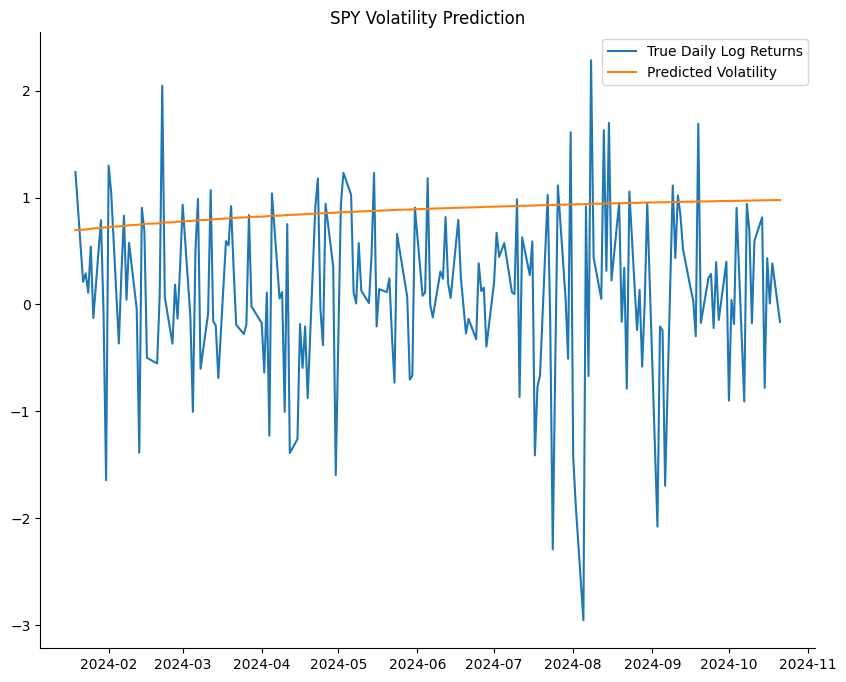

In [21]:
fig,ax = plt.subplots(figsize=(10,8))
ax.spines[['top','right']].set_visible(False)
# Plot test set returns
plt.plot(diff_ts[-y_test.shape[0]:])
# Plot volatility estimates for test set
plt.plot(y_test.index, np.sqrt(yhat.variance.values[-1,:]))
plt.title(f'{ticker} Volatility Prediction')
plt.legend(['True Daily Log Returns', 'Predicted Volatility'])

In [29]:
# Predict one step ahead

rolling_preds = []

for i in range(y_test.shape[0]):
    train = abs_returns[:-(y_test.shape[0]-i)]
    model = arch_model(train, p=1, q=1, rescale = False)
    model_fit = model.fit(disp='off')
    # One step ahead predictor
    pred = model_fit.forecast(horizon=1, reindex=True)
    rolling_preds.append(np.sqrt(pred.variance.values[-1,:][0]))

rolling_preds = pd.Series(rolling_preds, index=y_test.index)

Text(0.5, 1.0, 'SPY Rolling Volatility Prediction')

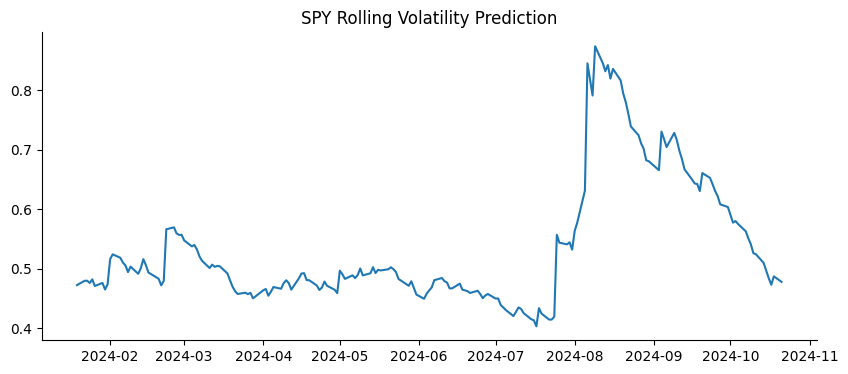

In [30]:
# Plot of predicted test data rolling volatility predictions
fig,ax = plt.subplots(figsize=(10,4))
ax.spines[['top','right']].set_visible(False)
plt.plot(rolling_preds)
plt.title(f'{ticker} Rolling Volatility Prediction')

In [82]:
# # Compare n-step-ahead and one-step-ahead rolling predictions

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
# ax1.spines[['top','right']].set_visible(False)
# ax1.plot(diff_ts[-y_test.shape[0]:])
# ax1.plot(y_test.index, np.sqrt(yhat.variance.values[-1,:]))
# ax1.set_title("S&P 500 Volatility N-Step Predictions")
# ax1.legend(['True Daily Returns', 'Predicted Volatility'])

# ax.spines[['top','right']].set_visible(False)
# ax2.plot(diff_ts[-y_test.shape[0]:])
# ax2.plot(y_test.index,rolling_preds)
# ax2.set_title("S&P 500 Volatility Rolling Predictions")
# ax2.legend(['True Daily Returns', 'Predicted Rolling Volatility'])
# plt.show()

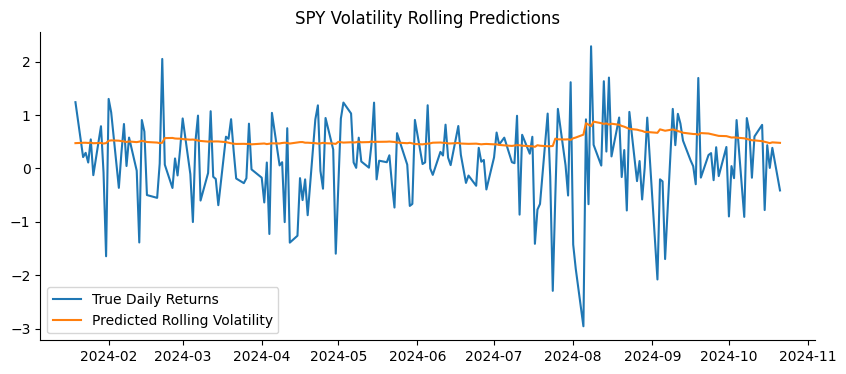

In [31]:
fig, ax2 = plt.subplots(figsize=(10, 4))
ax2.spines[['top', 'right']].set_visible(False)

ax2.plot(diff_ts[-y_test.shape[0]:])
ax2.plot(y_test.index, rolling_preds)
ax2.set_title(f"{ticker} Volatility Rolling Predictions")
ax2.legend(['True Daily Returns', 'Predicted Rolling Volatility'])

plt.show()


In [32]:
# Jarque-Bera test statistic

# H₀: The data has a normal distribution.
# Hₐ: The data does not have a normal distribution.

std_resid = res_garch.resid / res_garch.conditional_volatility

# Perform Jarque-Bera test using scipy.stats
jb_test = jarque_bera(std_resid)
print("Jarque-Bera test statistic:", jb_test[0])
print("p-value:", jb_test[1])

if jb_test[1].item() < 0.05:
    print("Reject H0: The data do not have statistical normal distribution")
else:
    print("No reject H0: Data have normal distribution.")

Jarque-Bera test statistic: 18.04007095066499
p-value: 0.0001209618350013779
Reject H0: The data do not have statistical normal distribution


T-Student distribution

In [80]:
garch_mod = arch_model(y_train, mean = "Zero",  vol='Garch', p=1, q=1, dist = 't', rescale=False)
res_garch = garch_mod.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 3600.8856196044926
Iteration:      2,   Func. Count:     16,   Neg. LLF: 5805.6387121711505
Iteration:      3,   Func. Count:     22,   Neg. LLF: 1084.5404052431647
Iteration:      4,   Func. Count:     28,   Neg. LLF: 1104.3919474864838
Iteration:      5,   Func. Count:     34,   Neg. LLF: 1083.1540546499423
Iteration:      6,   Func. Count:     40,   Neg. LLF: 1093.9445612997138
Iteration:      7,   Func. Count:     46,   Neg. LLF: 1085.6572502319573
Iteration:      8,   Func. Count:     53,   Neg. LLF: 1082.7476422331956
Iteration:      9,   Func. Count:     58,   Neg. LLF: 1082.6566228477886
Iteration:     10,   Func. Count:     63,   Neg. LLF: 1082.5423219428249
Iteration:     11,   Func. Count:     68,   Neg. LLF: 1082.5112108710578
Iteration:     12,   Func. Count:     73,   Neg. LLF: 1082.5040421467188
Iteration:     13,   Func. Count:     78,   Neg. LLF: 1082.5031410187112
Iteration:     14,   Func. Count:     83,   Neg. LL

In [81]:
# Model summary 
print(res_garch.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                            GARCH   Log-Likelihood:               -1082.50
Distribution:      Standardized Student's t   AIC:                           2173.01
Method:                  Maximum Likelihood   BIC:                           2191.56
                                              No. Observations:                  763
Date:                      Mon, Oct 21 2024   Df Residuals:                      763
Time:                              18:43:53   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
o

In [82]:
# Predict one step ahead

rolling_preds = []

for i in range(y_test.shape[0]):
    train = abs_returns[:-(y_test.shape[0]-i)]
    model = arch_model(train, p=2, q=1, rescale = False, dist = 't')
    model_fit = model.fit(disp='off')
    # One step ahead predictor
    pred = model_fit.forecast(horizon=1, reindex=True)
    rolling_preds.append(np.sqrt(pred.variance.values[-1,:][0]))

rolling_preds = pd.Series(rolling_preds, index=y_test.index)

In [83]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, rolling_preds)
print("MSE:", mse)


MSE: 0.8029503905410177


Text(0.5, 1.0, 'SPY Rolling Volatility Prediction')

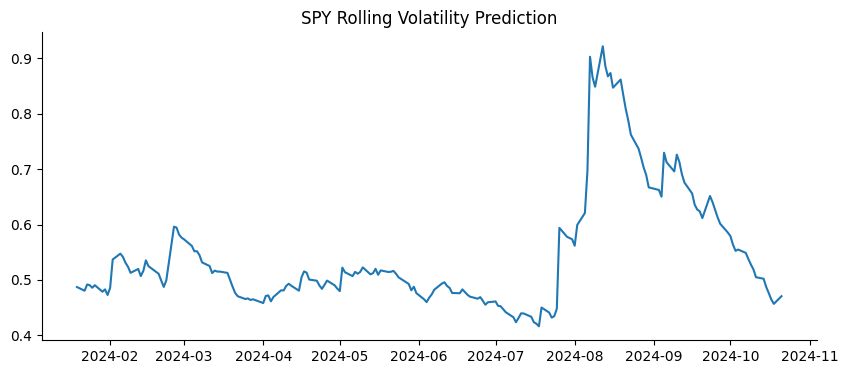

In [84]:
# Plot of predicted test data rolling volatility predictions
fig,ax = plt.subplots(figsize=(10,4))
ax.spines[['top','right']].set_visible(False)
plt.plot(rolling_preds)
plt.title(f'{ticker} Rolling Volatility Prediction')

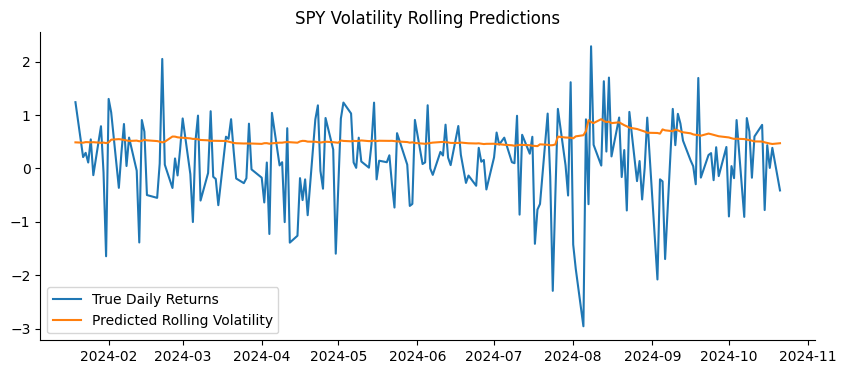

In [36]:
fig, ax2 = plt.subplots(figsize=(10, 4))
ax2.spines[['top', 'right']].set_visible(False)

ax2.plot(diff_ts[-y_test.shape[0]:])
ax2.plot(y_test.index, rolling_preds)
ax2.set_title(f"{ticker} Volatility Rolling Predictions")
ax2.legend(['True Daily Returns', 'Predicted Rolling Volatility'])

plt.show()


In [44]:
# Jarque-Bera test statistic

# H₀: The data has a normal distribution.
# Hₐ: The data does not have a normal distribution.

std_resid = res_garch.resid / res_garch.conditional_volatility

# Perform Jarque-Bera test using scipy.stats
jb_test = jarque_bera(std_resid)
print("Jarque-Bera test statistic:", jb_test[0])
print("p-value:", jb_test[1])

if jb_test[1].item() < 0.05:
    print("Reject H0: The data do not have statistical normal distribution")
else:
    print("No reject H0: Data have normal distribution.")

Jarque-Bera test statistic: 19.557888745388702
p-value: 5.663154631142756e-05
Reject H0: The data do not have statistical normal distribution


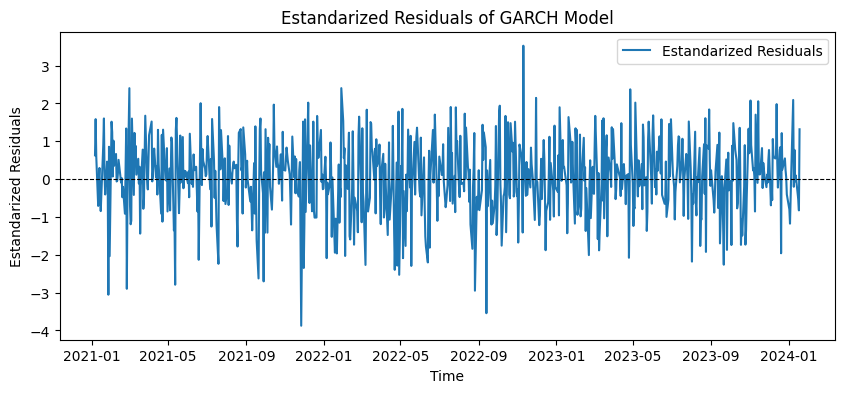

In [38]:
# Plot Estandarized residuals
plt.figure(figsize=(10, 4))
plt.plot(std_resid, label='Estandarized Residuals')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Estandarized Residuals of GARCH Model')
plt.xlabel('Time')
plt.ylabel('Estandarized Residuals')
plt.legend()
plt.show()


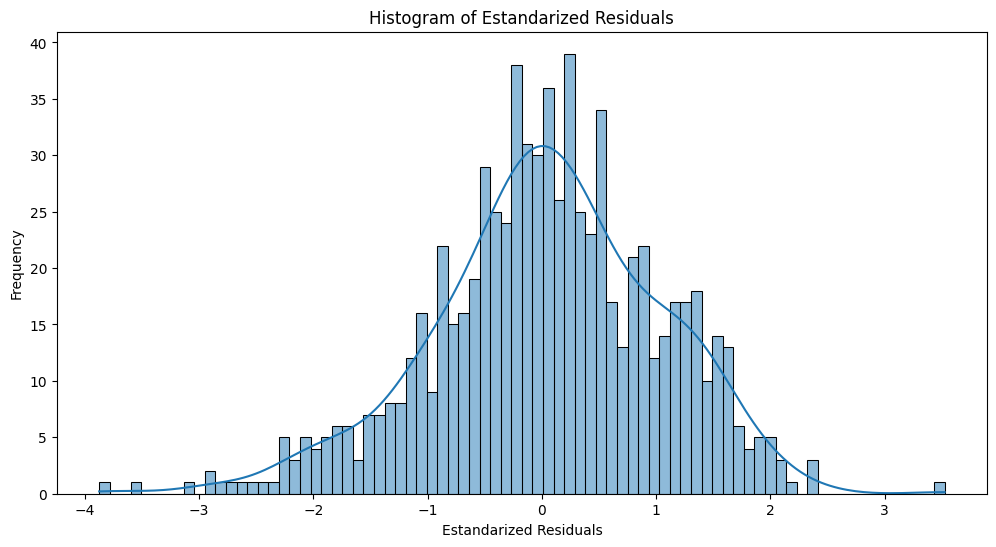

In [39]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(std_resid, bins=80, kde=True)
plt.title('Histogram of Estandarized Residuals')
plt.xlabel('Estandarized Residuals')
plt.ylabel('Frequency')
plt.show()


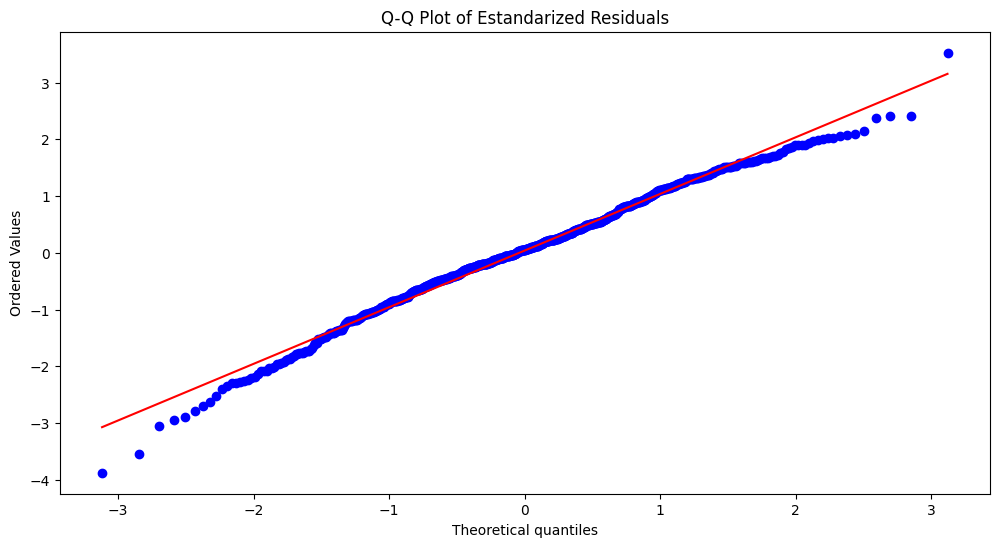

In [40]:
import scipy.stats as stats

plt.figure(figsize=(12, 6))
stats.probplot(std_resid, dist="norm", plot=plt)
plt.title('Q-Q Plot of Estandarized Residuals')
plt.show()


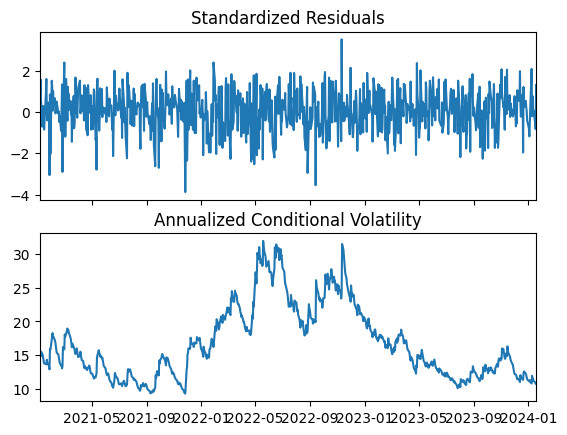

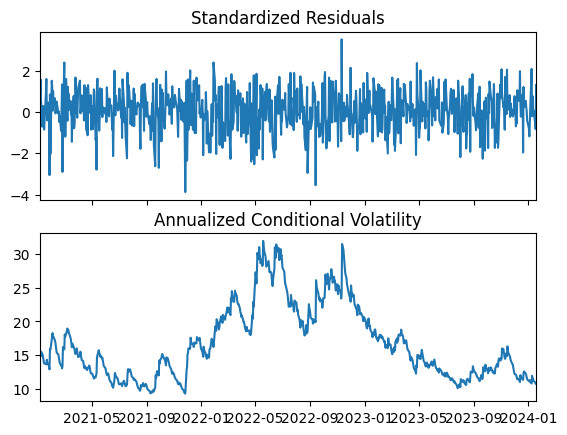

In [41]:
res_garch.plot(annualize="D")

Exponential GARCH

In [66]:
from arch import arch_model
import pandas as pd
from tqdm import tqdm  # Importar tqdm

results_list = []

p_values = [1, 2, 3, 4, 5, 6, 7, 8, 9]
q_values = [1, 2, 3, 4, 5, 6, 7, 8, 9]
distributions = ['normal', 't']

total_iterations = len(p_values) * len(q_values) * len(distributions)

with tqdm(total=total_iterations, desc='Fitting GARCH Models') as pbar:
    for p in p_values:
        for q in q_values:
            for dist in distributions:
                model = arch_model(y_train, mean='Zero', vol='EGARCH', p=p, q=q, dist=dist)
                res = model.fit(disp='off')
                
                results_list.append([
                    f'GARCH({p},{q})', p, q, dist, res.aic, res.bic])
                
                pbar.update(1)

results = pd.DataFrame(results_list, columns=['Model', 'p', 'q', 'Dist', 'AIC', 'BIC'])

best_model_aic = results.loc[results['AIC'].idxmin()]
best_model_bic = results.loc[results['BIC'].idxmin()]


Fitting GARCH Models: 100%|██████████| 162/162 [00:09<00:00, 16.45it/s]


In [70]:
# Fit GARCH (1,1)
# y_train, y_test = train_test_split(abs_returns, train_size= 0.8)

garch_mod = arch_model(y_train, mean = "Zero",  vol='EGARCH', p=1, q=1, rescale=False)
res_garch = garch_mod.fit()

Iteration:      1,   Func. Count:      5,   Neg. LLF: 5954.645583610264
Iteration:      2,   Func. Count:     13,   Neg. LLF: 222144331.19418168
Iteration:      3,   Func. Count:     21,   Neg. LLF: 1091.4583409498005
Iteration:      4,   Func. Count:     26,   Neg. LLF: 1087.3231016298337
Iteration:      5,   Func. Count:     31,   Neg. LLF: 5561.511482221211
Iteration:      6,   Func. Count:     37,   Neg. LLF: 1087.5330469004557
Iteration:      7,   Func. Count:     42,   Neg. LLF: 1085.4834739513321
Iteration:      8,   Func. Count:     46,   Neg. LLF: 1085.477854447502
Iteration:      9,   Func. Count:     50,   Neg. LLF: 1085.4780814509181
Iteration:     10,   Func. Count:     55,   Neg. LLF: 1085.4774575253712
Iteration:     11,   Func. Count:     59,   Neg. LLF: 1085.4774515024549
Iteration:     12,   Func. Count:     62,   Neg. LLF: 1085.477451502575
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1085.4774515024549
            Iterati

In [71]:
# Model summary 
print(res_garch.summary())

                       Zero Mean - EGARCH Model Results                       
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                     EGARCH   Log-Likelihood:               -1085.48
Distribution:                  Normal   AIC:                           2176.95
Method:            Maximum Likelihood   BIC:                           2190.87
                                        No. Observations:                  763
Date:                Mon, Oct 21 2024   Df Residuals:                      763
Time:                        18:42:20   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      1.4911e-03  2.944e-03      0.506      0.613 

In [72]:
# Predict one step ahead

rolling_preds = []

for i in range(y_test.shape[0]):
    train = abs_returns[:-(y_test.shape[0]-i)]
    model = arch_model(train, mean='Zero', vol='EGARCH', p=p, q=q, dist=dist)
    model_fit = model.fit(disp='off')
    # One step ahead predictor
    pred = model_fit.forecast(horizon=1, reindex=True)
    rolling_preds.append(np.sqrt(pred.variance.values[-1,:][0]))

rolling_preds = pd.Series(rolling_preds, index=y_test.index)

Text(0.5, 1.0, 'SPY Rolling Volatility Prediction')

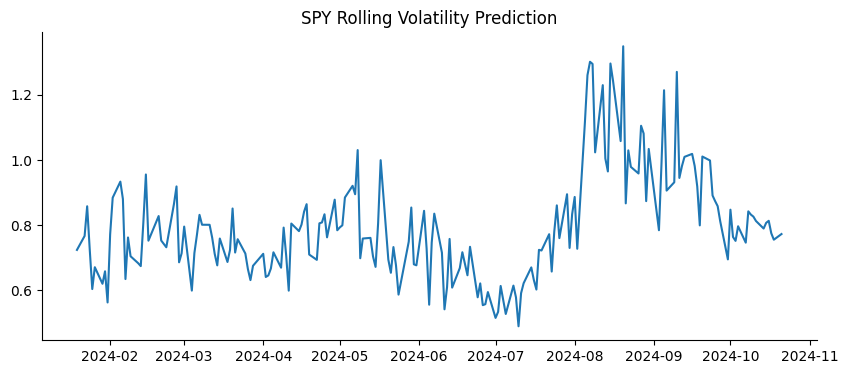

In [73]:
# Plot of predicted test data rolling volatility predictions
fig,ax = plt.subplots(figsize=(10,4))
ax.spines[['top','right']].set_visible(False)
plt.plot(rolling_preds)
plt.title(f'{ticker} Rolling Volatility Prediction')

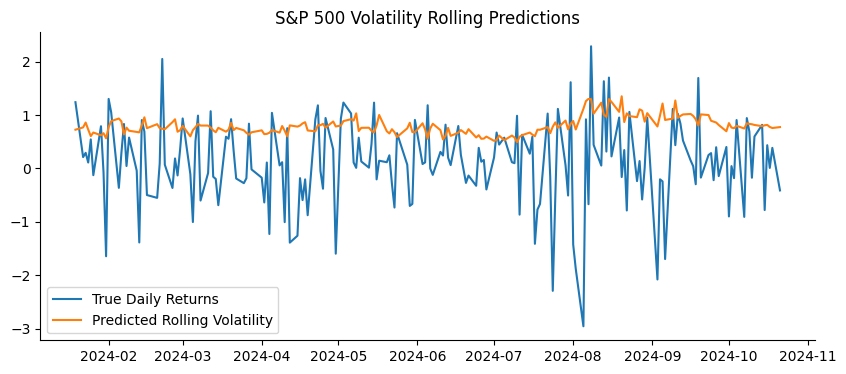

In [74]:
import matplotlib.pyplot as plt

fig, ax2 = plt.subplots(figsize=(10, 4))
ax2.spines[['top', 'right']].set_visible(False)

ax2.plot(diff_ts[-y_test.shape[0]:])
ax2.plot(y_test.index, rolling_preds)
ax2.set_title("S&P 500 Volatility Rolling Predictions")
ax2.legend(['True Daily Returns', 'Predicted Rolling Volatility'])

plt.show()


In [75]:
# Jarque-Bera test statistic

# H₀: The data has a normal distribution.
# Hₐ: The data does not have a normal distribution.


std_resid = res_garch.resid / res_garch.conditional_volatility

# Perform Jarque-Bera test using scipy.stats
jb_test = jarque_bera(std_resid)
print("Jarque-Bera test statistic:", jb_test[0])
print("p-value:", jb_test[1])

if jb_test[1].item() < 0.05:
    print("Reject H0: The data do not have statistical normal distribution")
else:
    print("No reject H0: Data have normal distribution.")

Jarque-Bera test statistic: 18.391730284638623
p-value: 0.0001014580503132944
Reject H0: The data do not have statistical normal distribution


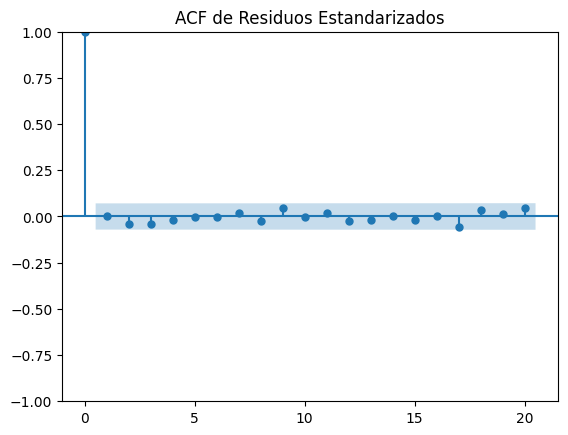

In [76]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(std_resid, lags=20)
plt.title("ACF de Residuos Estandarizados")
plt.show()


In [77]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(std_resid, lags=[10], return_df=True)
print(lb_test)


     lb_stat  lb_pvalue
10  5.294331   0.870669


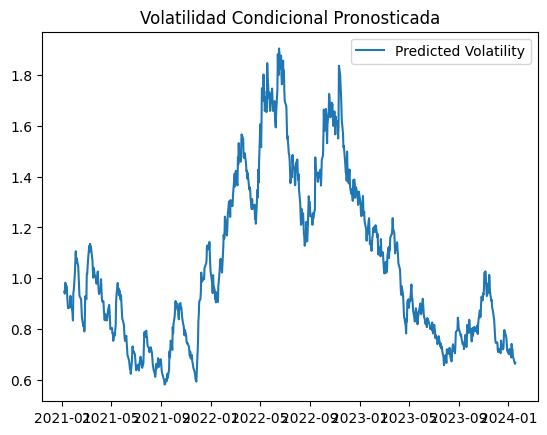

In [78]:
plt.plot(res_garch.conditional_volatility, label='Predicted Volatility')
plt.title("Volatilidad Condicional Pronosticada")
plt.legend()
plt.show()


In [79]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, rolling_preds)
print("MSE:", mse)


MSE: 1.1033570000831265


Quiebres en la serie

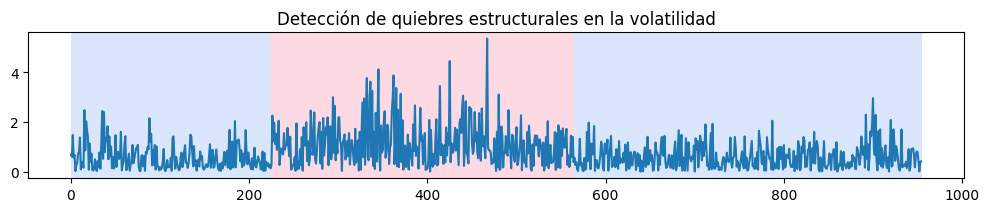

In [65]:
# Model L1  -> Modela distancia en valor absoluto desde la media 
# Model L2  -> Modela distancia al cuadrado desde la media
# Model rbf -> Modela Radial Basis Function

import ruptures as rpt
import matplotlib.pyplot as plt

log_return_array = abs(df['log_return']).values.reshape(-1, 1)

model = 'rbf'

algo = rpt.Pelt(model=model).fit(log_return_array)
breakpoints = algo.predict(pen=5)

# Visualizar los quiebres
rpt.display(abs(df['log_return']), breakpoints)
plt.title("Detección de quiebres estructurales en la volatilidad")
plt.show()
